# Extended Data 03 — Exposure-dependent construction margins

This notebook tests whether the associations of roof material, near-structure vegetation and building vintage vary across realized geometric coupling, $F^*$. It reproduces the analysis supporting the statement that construction attributes provide their largest margin within the intermediate-exposure fragility transition and become less differentiating as destruction approaches saturation.

In [1]:
import json
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import pandas as pd
from IPython.display import display

from src.analysis.construction import prepare_construction_samples
from src.analysis.construction_sensitivity import (
    exposure_dependent_margins, fit_exposure_interactions,
)
from src.analysis.population_audit import sha256
from src.viz.construction_sensitivity import plot_exposure_dependent_margins

DATA = PROJECT_ROOT / 'data'
RESULTS = PACKAGE_ROOT / 'results'
SOURCE_DATA = PACKAGE_ROOT / 'data' / 'derived'
FIGURES = PACKAGE_ROOT / 'figures' / 'extended_data'
for directory in [RESULTS, SOURCE_DATA, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)

## Analysis population

The analysis uses exposed, undefended structures with known roof material, vegetation and construction year—the complete sample used by the mutually adjusted construction model.

In [2]:
manifest = json.loads((RESULTS / 'analysis_manifest.json').read_text())
analysis_path = DATA / 'analysis.parquet'
assert sha256(analysis_path) == manifest['inputs']['analysis']['sha256']
analysis = pd.read_parquet(analysis_path)
samples = prepare_construction_samples(analysis)
construction = samples.complete.copy()
print(f'Complete exposed and undefended sample: {len(construction):,} structures')
display(construction.groupby('fire', observed=True).size().rename('n').reset_index())

Complete exposed and undefended sample: 21,288 structures


,fire,n
0,EATON,12420
1,PALISADES,8868


## Exposure-by-attribute model

A pooled logistic model includes interactions between $\log F^*$ and roof material, vegetation and continuous building vintage, with adjustment for fire. A likelihood-ratio test compares this specification with the corresponding additive model. Cluster-robust covariance uses the same approximately 250-m spatial grid as the primary construction analysis.

In [3]:
interaction_model, interaction_test = fit_exposure_interactions(construction)
interaction_test = pd.DataFrame([interaction_test])
interaction_test.to_csv(RESULTS / 'ED03_construction_interaction_test.csv', index=False)
display(interaction_test)

,analysis_n,lr_chi2,degrees_freedom,p_value
0,21288,197.392027,7,4.093232e-39


## Standardized protective margins

For each exposure value, predicted destruction is standardized over the observed analysis population under two attribute settings. Tile is compared with asphalt; lower vegetation with the 75th-to-25th percentile reduction in NDVI; and newer construction with the 25th-to-75th percentile increase in construction year. The reported margin is the predicted percentage-point reduction in destruction. Confidence bands simulate coefficients from the cluster-robust covariance matrix.

In [4]:
margin_curves, margin_summary = exposure_dependent_margins(
    construction, interaction_model, n_grid=60, n_draws=300, seed=20250808
)
margin_curves.to_csv(
    SOURCE_DATA / 'ED_fig_construction_exposure_margins_source.csv', index=False
)
margin_summary.to_csv(
    RESULTS / 'ED03_construction_exposure_margin_summary.csv', index=False
)
display(margin_summary.round(3))

,attribute,contrast,analysis_n,peak_margin_pp,peak_F_star,peak_exposure_percentile,margin_at_p98_pp,F_star_below_5pp_after_peak,percentile_below_5pp_after_peak
0,Tile roofing,Tile rather than asphalt,21288,7.296,0.067,51.508,2.707,0.243,84.409
1,Lower vegetation,25th rather than 75th percentile NDVI,21288,8.749,0.022,34.888,0.833,0.093,59.315
2,Newer construction,75th rather than 25th percentile construction ...,21288,3.164,0.093,59.315,1.329,0.109,63.684


saved ./figures/extended_data/ED_fig_construction_exposure_margins.pdf


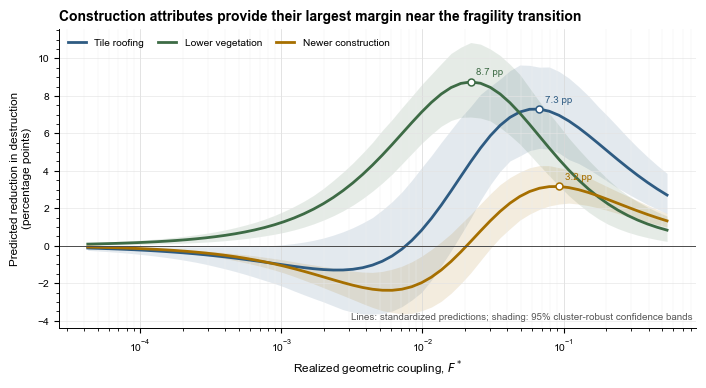

In [5]:
fig = plot_exposure_dependent_margins(margin_curves, margin_summary, FIGURES)
print('saved', FIGURES / 'ED_fig_construction_exposure_margins.pdf')

## Interpretation

These curves are model-standardized associations, not component-level causal effects. A narrowing margin at high $F^*$ indicates that the evaluated attributes distinguish outcomes less once the destruction response approaches saturation; it does not imply that an attribute physically ceases to function.